In [1]:
# ==========================================
# BLOQUE 1: IMPORTACIONES Y OPTIMIZACIÓN DE HARDWARE
# ==========================================
import tensorflow as tf
import os
import glob
import time
import matplotlib.pyplot as plt
from IPython import display

print(f"TensorFlow Version: {tf.__version__}")

# 1. OPTIMIZACIÓN DE MEMORIA: PRECISION MIXTA (Mixed Precision)
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

print(f"Política de Precisión actual: {policy.name}")
print(f"Compute dtype: {policy.compute_dtype}")
print(f"Variable dtype: {policy.variable_dtype}")

# 2. DEFINICIÓN DE PARÁMETROS GLOBALES
BUFFER_SIZE = 1000 
BATCH_SIZE = 8
IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_ORIGINAL_SIZE = 1024 

# Solo apuntamos a la carpeta de COLOR. Las otras se deducirán automáticamente.
PATH_COLOR = '/kaggle/input/datasets/mjgut05/matsynth-pbr-cleaned/matsynth_dataset/rgb/*.png'

# Creación de carpetas para la exportación de texturas puras
os.makedirs('/kaggle/working/Normales_Puras', exist_ok=True)
os.makedirs('/kaggle/working/Roughness_Puras', exist_ok=True)
print("Carpetas de exportación puras creadas correctamente.")

2026-04-05 18:28:37.207355: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775413717.450519      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775413717.522147      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775413718.093291      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775413718.093352      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775413718.093355      24 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
Política de Precisión actual: mixed_float16
Compute dtype: float16
Variable dtype: float32
Carpetas de exportación puras creadas correctamente.


In [2]:
# ==========================================
# BLOQUE 2: CARGA ROBUSTA (Rutas Estrictas) Y AUMENTO DE DATOS
# ==========================================
def decode_robust(file_path, channels):
    """
    Decodificador blindado versión 2.0.
    Fuerza la lectura en 8-bits. Si el archivo es de 16-bits, TensorFlow tomará 
    solo los bytes significativos, manteniendo la escala visual intacta (0-255).
    """
    img_bytes = tf.io.read_file(file_path)
    
    # Forzamos decode_png con uint8 explícito (ignora metadatos extraños de 16-bits)
    img = tf.io.decode_png(img_bytes, channels=channels, dtype=tf.uint8)
    
    # Usamos cast puro en lugar de convert_image_dtype. 
    # Cast simplemente cambia de int a float manteniendo los valores entre 0 y 255.
    img = tf.cast(img, tf.float32) 
    
    return img

def load_paired_images(color_path):
    """
    Carga emparejada basada ESTRICTAMENTE en carpetas.
    Reemplazamos '/rgb/' por sus respectivas carpetas.
    """
    # ¡AQUÍ ESTABA EL ERROR! Cambiamos '/color/' por '/rgb/'
    normal_path = tf.strings.regex_replace(color_path, '/rgb/', '/normal/')
    rough_path = tf.strings.regex_replace(color_path, '/rgb/', '/roughness/')

    # Carga blindada (16-bits/8-bits) usando la función decode_robust
    color_img = decode_robust(color_path, 3)
    normal_img = decode_robust(normal_path, 3)
    roughness_img = decode_robust(rough_path, 1)

    # Fusión del Target (Normal(3) + Roughness(1) = 4 canales)
    target_img = tf.concat([normal_img, roughness_img], axis=-1)
    return color_img, target_img

def resize_for_crop(input_image, target_image, height, width):
    input_image = tf.image.resize(input_image, [height, width], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    target_image = tf.image.resize(target_image, [height, width], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    return input_image, target_image

def random_crop(input_image, target_image):
    stacked_image = tf.concat([input_image, target_image], axis=-1)
    cropped_image = tf.image.random_crop(stacked_image, size=[IMG_HEIGHT, IMG_WIDTH, 7])
    return cropped_image[..., :3], cropped_image[..., 3:]

@tf.function()
def random_jitter(input_image, target_image):
    input_image, target_image = resize_for_crop(input_image, target_image, IMG_ORIGINAL_SIZE, IMG_ORIGINAL_SIZE)
    input_image, target_image = random_crop(input_image, target_image)

    # FLIP HORIZONTAL (Espejo en Eje X)
    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        target_image = tf.image.flip_left_right(target_image)
        r, g, b, a = tf.split(target_image, 4, axis=-1)
        r = 255.0 - r 
        target_image = tf.concat([r, g, b, a], axis=-1)

    # FLIP VERTICAL (Espejo en Eje Y)
    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_up_down(input_image)
        target_image = tf.image.flip_up_down(target_image)
        r, g, b, a = tf.split(target_image, 4, axis=-1)
        g = 255.0 - g 
        target_image = tf.concat([r, g, b, a], axis=-1)

    # COLOR JITTERING
    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.random_brightness(input_image, max_delta=0.2)
        input_image = tf.image.random_contrast(input_image, lower=0.8, upper=1.2)
        input_image = tf.image.random_saturation(input_image, lower=0.8, upper=1.2)
        input_image = tf.clip_by_value(input_image, 0.0, 255.0)

    return input_image, target_image

def normalize(input_image, target_image):
    input_image = (input_image / 127.5) - 1.0
    target_image = (target_image / 127.5) - 1.0
    return input_image, target_image

In [3]:
# ==========================================
# BLOQUE 3: PIPELINE DE RENDIMIENTO Y DIVISIÓN AUTOMÁTICA
# ==========================================
def load_image_train(image_path):
    input_image, target_image = load_paired_images(image_path)
    input_image, target_image = random_jitter(input_image, target_image)
    input_image, target_image = normalize(input_image, target_image)
    return input_image, target_image

def load_image_test(image_path):
    input_image, target_image = load_paired_images(image_path)
    input_image, target_image = resize_for_crop(input_image, target_image, IMG_HEIGHT, IMG_WIDTH)
    input_image, target_image = normalize(input_image, target_image)
    return input_image, target_image

AUTOTUNE = tf.data.AUTOTUNE

# 1. Contamos cuántas imágenes hay SOLO en la carpeta de color
total_materiales = len(glob.glob(PATH_COLOR))
print(f"Materiales PBR totales detectados: {total_materiales}")

# 2. Calculamos 90/10
train_size = int(total_materiales * 0.9)

# 3. Barajamos las rutas con semilla fija para no contaminar el Test
todas_las_rutas = tf.data.Dataset.list_files(PATH_COLOR, shuffle=True, seed=42)

rutas_train = todas_las_rutas.take(train_size)
rutas_test = todas_las_rutas.skip(train_size)

print(f"Asignados a Entrenamiento: {train_size} materiales")
print(f"Asignados a Pruebas (Test): {total_materiales - train_size} materiales")

# 4. Construcción del Pipeline
train_dataset = rutas_train.map(load_image_train, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

test_dataset = rutas_test.map(load_image_test, num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("¡Pipeline tf.data (Emparejado Dinámico) construido con éxito!")

Materiales PBR totales detectados: 1483


I0000 00:00:1775413746.459054      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Asignados a Entrenamiento: 1334 materiales
Asignados a Pruebas (Test): 149 materiales
¡Pipeline tf.data (Emparejado Dinámico) construido con éxito!


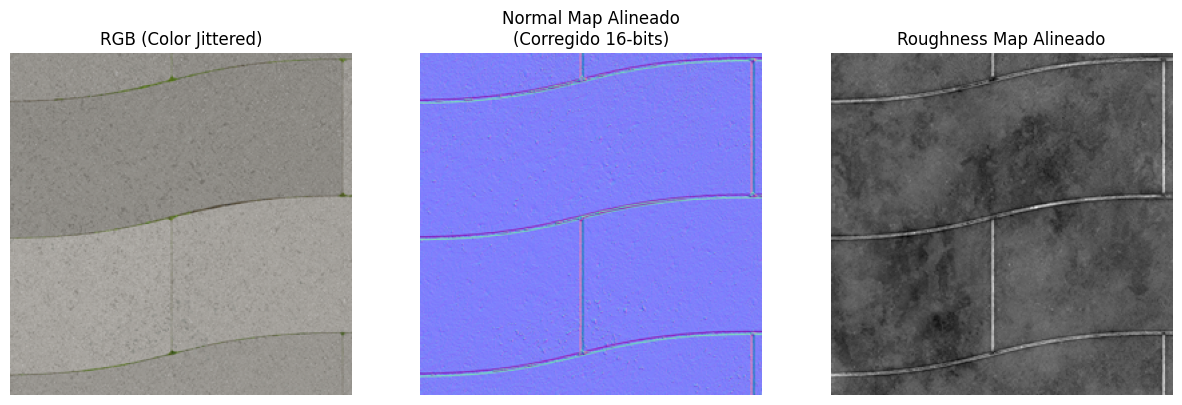

--- TELEMETRÍA DE TENSORES (Matemática Interna) ---
Shape del Input: (8, 256, 256, 3)
Shape del Target: (8, 256, 256, 4)
Rango de valores RGB: [-0.89, 0.49] (Debe estar entre -1.0 y 1.0)
Rango Normal Map: [-0.76, 1.00] (Debe estar entre -1.0 y 1.0)
Rango Roughness: [0.01, 0.70] (Debe estar entre -1.0 y 1.0)


In [4]:
# ==========================================
# BLOQUE 4: VALIDACIÓN VISUAL Y TELEMETRÍA DE TENSORES
# ==========================================
for example_input, example_target in train_dataset.take(1):
    
    inp = example_input[0]
    tar = example_target[0]
    
    # Desnormalizamos para Matplotlib [0, 1]
    inp_show = (inp + 1.0) / 2.0
    norm_show = (tar[:, :, :3] + 1.0) / 2.0
    rough_show = (tar[:, :, 3] + 1.0) / 2.0

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("RGB (Color Jittered)")
    plt.imshow(inp_show)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("Normal Map Alineado\n(Corregido 16-bits)")
    plt.imshow(norm_show)
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("Roughness Map Alineado")
    plt.imshow(rough_show, cmap='gray')
    plt.axis('off')
    
    plt.show()
    
    # --- PRUEBA MATEMÁTICA DEL ALGODÓN ---
    print("--- TELEMETRÍA DE TENSORES (Matemática Interna) ---")
    print(f"Shape del Input: {example_input.shape}")
    print(f"Shape del Target: {example_target.shape}")
    print(f"Rango de valores RGB: [{tf.reduce_min(inp):.2f}, {tf.reduce_max(inp):.2f}] (Debe estar entre -1.0 y 1.0)")
    print(f"Rango Normal Map: [{tf.reduce_min(tar[:, :, :3]):.2f}, {tf.reduce_max(tar[:, :, :3]):.2f}] (Debe estar entre -1.0 y 1.0)")
    print(f"Rango Roughness: [{tf.reduce_min(tar[:, :, 3]):.2f}, {tf.reduce_max(tar[:, :, 3]):.2f}] (Debe estar entre -1.0 y 1.0)")
    break

In [5]:
# ==========================================
# BLOQUE 5: MECANISMOS DE ATENCIÓN (CBAM)
# ==========================================
from tensorflow.keras import layers

def cbam_block(input_feature, ratio=8):
    """
    Convolutional Block Attention Module (CBAM).
    Combina Atención de Canal (Qué características son importantes) 
    y Atención Espacial (Dónde están las características importantes).
    """
    # --- 1. Channel Attention ---
    # ¿Qué filtros de la convolución tienen información útil (ej. porosidad vs color)?
    channels = input_feature.shape[-1]
    
    shared_layer_one = layers.Dense(channels // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True)
    shared_layer_two = layers.Dense(channels, kernel_initializer='he_normal', use_bias=True)
    
    # Global Average Pooling
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channels))(avg_pool)
    avg_pool = shared_layer_two(shared_layer_one(avg_pool))
    
    # Global Max Pooling
    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channels))(max_pool)
    max_pool = shared_layer_two(shared_layer_one(max_pool))
    
    cbam_feature = layers.Multiply()([input_feature, layers.Activation('sigmoid')(layers.Add()([avg_pool, max_pool]))])
    
    # --- 2. Spatial Attention ---
    # ¿En qué coordenadas X,Y de la imagen está la geometría clave (bordes/grietas)?
    # Envolvemos las operaciones de TensorFlow en layers.Lambda
    spatial_avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(cbam_feature)
    spatial_max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(cbam_feature)
    
    concat = layers.Concatenate(axis=-1)([spatial_avg_pool, spatial_max_pool])
    
    cbam_feature = layers.Multiply()([cbam_feature, layers.Activation('sigmoid')(layers.Conv2D(1, (7,7), padding='same', activation=None)(concat))])
    
    return cbam_feature

In [6]:
# ==========================================
# BLOQUE 6: COMPONENTES DEL DECODER
# ==========================================
def upsample_block(filters, size, apply_dropout=False, apply_attention=True):
    """
    Bloque de subida para los Decoders. Escala la imagen x2 en resolución.
    Integra BatchNormalization, y opcionalmente Dropout y CBAM Attention.
    """
    initializer = tf.random_normal_initializer(0., 0.02)
    
    result = tf.keras.Sequential()
    # Conv2DTranspose multiplica el tamaño espacial x2 (ej. de 16x16 pasa a 32x32)
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same',
                                      kernel_initializer=initializer, use_bias=False))
    
    result.add(layers.BatchNormalization())
    
    if apply_dropout:
        result.add(layers.Dropout(0.5))
        
    result.add(layers.ReLU())
    
    return result

In [7]:
# ==========================================
# BLOQUE 7: ARQUITECTURA DEEP-PBR NET (DUAL HEAD)
# ==========================================

def build_deep_pbr_generator():
    """
    Generador Avanzado: Backbone ResNet50 + Skip Connections con CBAM + Dos Cabezas.
    """
    inputs = layers.Input(shape=[256, 256, 3])

    # 1. ENCODER (ResNet50 Backbone preentrenado)
    base_model = tf.keras.applications.ResNet50(input_tensor=inputs, include_top=False, weights='imagenet')

    # --- DESCONGELAMIENTO (FASE 3) ---
    base_model.trainable = True

    # ESTRATEGIA CAUTELOSA: En la Fase 2 congelamos 100. Ahora congelamos 80.
    # Liberamos solo un bloque profundo más para que gane detalle sin colapsar.
    for layer in base_model.layers[:80]:
        layer.trainable = False
    
    # Extraemos las capas específicas para usarlas de "puentes" (Skip Connections)
    # Dimensiones para input 256x256:
    skip_names = [
        'conv1_relu',           # 128x128x64
        'conv2_block3_out',     # 64x64x256
        'conv3_block4_out',     # 32x32x512
        'conv4_block6_out',     # 16x16x1024
    ]
    skips = [base_model.get_layer(name).output for name in skip_names]
    
    # El fondo del "embudo" (Cuello de botella)
    bottleneck = base_model.get_layer('conv5_block3_out').output # 8x8x2048
    
    # --- CABEZA A: DECODER NORMAL MAP (GEOMETRÍA) ---
    def build_decoder_head(x, head_name, output_channels):
        # Arrays de filtros para ir subiendo desde 8x8 hasta 128x128
        up_filters = [1024, 512, 256, 64]
        
        # Iteramos en reversa sobre las skip connections
        for skip, filters in zip(reversed(skips), up_filters):
            x = upsample_block(filters, 4)(x)
            
            # Aplicar Mecanismo de Atención al puente antes de concatenar
            skip_attended = cbam_block(skip)
            
            x = layers.Concatenate()([x, skip_attended])
            
        # Último paso: Subir de 128x128 a 256x256
        initializer = tf.random_normal_initializer(0., 0.02)
        
        # CRÍTICO: dtype='float32'. Como estamos en Mixed Precision, la última capa 
        # DEBE escupir tensores en 32-bits para que la función de pérdida no colapse.
        last = layers.Conv2DTranspose(output_channels, 4, strides=2, padding='same',
                                      kernel_initializer=initializer, activation='tanh', 
                                      name=head_name, dtype='float32')
        return last(x)

    # Bifurcamos el modelo desde el cuello de botella
    normal_output = build_decoder_head(bottleneck, head_name='salida_normal', output_channels=3)
    roughness_output = build_decoder_head(bottleneck, head_name='salida_roughness', output_channels=1)

    # Ensamblamos el modelo definiendo 1 entrada y 2 salidas distintas
    return tf.keras.Model(inputs=inputs, outputs=[normal_output, roughness_output], name="DeepPBR_Generator")

# Instanciamos el modelo
generador_pbr = build_deep_pbr_generator()

# Prueba matemática de humo (Verificación de formas)
dummy_input = tf.random.normal([1, 256, 256, 3])
dummy_norm, dummy_rough = generador_pbr(dummy_input)

print("--- TELEMETRÍA DE LA ARQUITECTURA ---")
print(f"Salida Normal Map (Esperada 1x256x256x3): {dummy_norm.shape}")
print(f"Salida Roughness Map (Esperada 1x256x256x1): {dummy_rough.shape}")
print(f"Parámetros Totales del Generador: {generador_pbr.count_params():,}")
print("¡Generador actualizado Fase 6 Corregida (80 capas bloqueadas)!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1775413827.140522      24 cuda_dnn.cc:529] Loaded cuDNN version 91002


--- TELEMETRÍA DE LA ARQUITECTURA ---
Salida Normal Map (Esperada 1x256x256x3): (1, 256, 256, 3)
Salida Roughness Map (Esperada 1x256x256x1): (1, 256, 256, 1)
Parámetros Totales del Generador: 134,406,380
¡Generador actualizado Fase 6 Corregida (80 capas bloqueadas)!


In [8]:
# ==========================================
# BLOQUE 8: EL DISCRIMINADOR (PATCHGAN)
# ==========================================

def downsample_block(filters, size, apply_batchnorm=True):
    """Bloque de bajada de resolución para el Discriminador"""
    initializer = tf.random_normal_initializer(0., 0.02)
    
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
        
    result.add(layers.LeakyReLU())
    return result

def build_discriminator():
    """
    Discriminador PatchGAN. Recibe la imagen RGB Original y los mapas generados/reales,
    y juzga parche a parche si son auténticos o creados por la red.
    """
    initializer = tf.random_normal_initializer(0., 0.02)

    # Entradas
    inp = layers.Input(shape=[256, 256, 3], name='input_rgb')
    tar_normal = layers.Input(shape=[256, 256, 3], name='target_normal')
    tar_rough = layers.Input(shape=[256, 256, 1], name='target_roughness')

    # Concatenamos todo: 3 (RGB) + 3 (Normal) + 1 (Roughness) = Tensor de 7 canales
    x = layers.Concatenate()([inp, tar_normal, tar_rough])

    # Arquitectura PatchGAN clásica
    down1 = downsample_block(64, 4, apply_batchnorm=False)(x) # Baja a 128x128
    down2 = downsample_block(128, 4)(down1)                   # Baja a 64x64
    down3 = downsample_block(256, 4)(down2)                   # Baja a 32x32

    zero_pad1 = layers.ZeroPadding2D()(down3)                 # Relleno a 34x34
    conv = layers.Conv2D(512, 4, strides=1, kernel_initializer=initializer, use_bias=False)(zero_pad1) 
    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)
    
    # CRÍTICO: La salida debe ser float32 para la estabilidad de la función de pérdida
    last = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer, dtype='float32')(zero_pad2) 

    return tf.keras.Model(inputs=[inp, tar_normal, tar_rough], outputs=last, name="Discriminador_PatchGAN")

discriminador_pbr = build_discriminator()

print("--- TELEMETRÍA DEL DISCRIMINADOR ---")
print(f"Parámetros Totales del Discriminador: {discriminador_pbr.count_params():,}")

--- TELEMETRÍA DEL DISCRIMINADOR ---
Parámetros Totales del Discriminador: 2,771,457


In [9]:
# ==========================================
# BLOQUE 8.5: RED DE PÉRDIDA PERCEPTUAL (VGG19)
# ==========================================
# 1. Cargamos el modelo VGG19 preentrenado en ImageNet (Sin la cabeza de clasificación)
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False # ¡Crucial! No queremos que VGG aprenda, solo que juzgue.

# 2. Extraemos las características de una capa intermedia (block3_conv3). 
# Esta capa es famosa en la literatura científica por capturar "texturas" y "materiales".
perceptual_model = tf.keras.Model(inputs=vgg.input, outputs=vgg.get_layer('block3_conv3').output)

def calcular_vgg_loss(target, generated):
    """
    Toma imágenes en rango [-1, 1], las pasa al formato VGG [0, 255] 
    y calcula la diferencia de 'estilo/textura'.
    """
    # Escalar de [-1, 1] a [0, 255]
    target_scaled = (target + 1.0) * 127.5
    generated_scaled = (generated + 1.0) * 127.5
    
    # Preprocesado oficial de VGG19 (Resta la media de ImageNet)
    target_preprocessed = tf.keras.applications.vgg19.preprocess_input(target_scaled)
    generated_preprocessed = tf.keras.applications.vgg19.preprocess_input(generated_scaled)
    
    # Extraer mapas de características
    target_features = perceptual_model(target_preprocessed)
    generated_features = perceptual_model(generated_preprocessed)
    
    # Devolver la diferencia media absoluta (L1 sobre las características)
    return tf.reduce_mean(tf.abs(target_features - generated_features))

print("¡Juez de Arte VGG19 (Perceptual Loss) cargado en memoria!")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
¡Juez de Arte VGG19 (Perceptual Loss) cargado en memoria!


In [10]:
# ==========================================
# BLOQUE 9: REGLAS DEL JUEGO (FASE 6 - GDL + MULTI-ESCALA)
# ==========================================

LAMBDA_NORMAL = 50    
LAMBDA_ROUGH = 25     
LAMBDA_VGG = 2        # Mantenemos VGG baja para evitar estática
LAMBDA_GDL = 10       # Peso moderado para que afile bordes sin romper la red

loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# --- 1. NUEVA FUNCIÓN: L1 Multi-Escala ---
def multi_scale_l1(target, gen):
    # Escala original (256)
    l1_256 = tf.reduce_mean(tf.abs(target - gen))
    # Escala media (128)
    target_128 = tf.image.resize(target, [128, 128])
    gen_128 = tf.image.resize(gen, [128, 128])
    l1_128 = tf.reduce_mean(tf.abs(target_128 - gen_128))
    # Escala pequeña (64)
    target_64 = tf.image.resize(target, [64, 64])
    gen_64 = tf.image.resize(gen, [64, 64])
    l1_64 = tf.reduce_mean(tf.abs(target_64 - gen_64))
    
    # Sumamos dándole más peso a la resolución original
    return l1_256 + (0.5 * l1_128) + (0.25 * l1_64)

# --- 2. NUEVA FUNCIÓN: GDL (Gradient Difference Loss) ---
def compute_gdl(target, gen):
    # Calculamos los bordes verticales (diferencia en Y) y horizontales (diferencia en X)
    target_dy = tf.abs(target[:, 1:, :, :] - target[:, :-1, :, :])
    target_dx = tf.abs(target[:, :, 1:, :] - target[:, :, :-1, :])
    
    gen_dy = tf.abs(gen[:, 1:, :, :] - gen[:, :-1, :, :])
    gen_dx = tf.abs(gen[:, :, 1:, :] - gen[:, :, :-1, :])
    
    # Castigamos si el generador no hace los bordes igual que el original
    loss_dy = tf.reduce_mean(tf.abs(target_dy - gen_dy))
    loss_dx = tf.reduce_mean(tf.abs(target_dx - gen_dx))
    
    return loss_dy + loss_dx

# --- EL GENERADOR ---
def generator_loss(disc_generated_output, gen_normal, gen_rough, target_normal, target_rough):
    
    # 1. Pérdida Adversarial
    gan_loss = tf.cast(loss_object(tf.ones_like(disc_generated_output), disc_generated_output), tf.float32)

    # 2. Pérdida L1 Multi-Escala (Sustituye a la L1 normal)
    l1_loss_normal = tf.cast(multi_scale_l1(target_normal, gen_normal), tf.float32)
    l1_loss_rough = tf.cast(multi_scale_l1(target_rough, gen_rough), tf.float32)

    # 3. Pérdida Perceptual VGG19 (Baja intensidad)
    vgg_loss_normal = calcular_vgg_loss(target_normal, gen_normal)
    target_rough_3c = tf.tile(target_rough, [1, 1, 1, 3])
    gen_rough_3c = tf.tile(gen_rough, [1, 1, 1, 3])
    vgg_loss_rough = calcular_vgg_loss(target_rough_3c, gen_rough_3c)
    total_vgg_loss = tf.cast(vgg_loss_normal + vgg_loss_rough, tf.float32)

    # 4. GDL (Afilar texturas y juntas)
    gdl_normal = tf.cast(compute_gdl(target_normal, gen_normal), tf.float32)
    gdl_rough = tf.cast(compute_gdl(target_rough, gen_rough), tf.float32)
    total_gdl = gdl_normal + gdl_rough

    # Ecuación Final del Generador
    total_gen_loss = gan_loss + (LAMBDA_NORMAL * l1_loss_normal) + \
                     (LAMBDA_ROUGH * l1_loss_rough) + \
                     (LAMBDA_VGG * total_vgg_loss) + \
                     (LAMBDA_GDL * total_gdl)
                     
    return total_gen_loss, gan_loss, l1_loss_normal, l1_loss_rough, total_vgg_loss, total_gdl

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    return tf.cast(real_loss + generated_loss, tf.float32)

# --- OPTIMIZADORES (MODO MICRO-CONGELACIÓN) ---
# Bajamos la velocidad al mínimo absoluto (1e-7) para asentar los pesos.
# El discriminador lo bajamos aún más (1e-8) para que no sea agresivo en esta fase final.
generator_optimizer = tf.keras.optimizers.Adam(1e-7, beta_1=0.5) 
discriminator_optimizer = tf.keras.optimizers.Adam(1e-8, beta_1=0.5)

print("¡Optimizadores en modo Micro-Congelación cargados!")

¡Optimizadores en modo Micro-Congelación cargados!


In [11]:
# ==========================================
# BLOQUE 10: EL MOTOR DE APRENDIZAJE
# ==========================================
@tf.function
def train_step(input_image, target_normal, target_rough):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_normal, gen_rough = generador_pbr(input_image, training=True)

        disc_real_output = discriminador_pbr([input_image, target_normal, target_rough], training=True)
        disc_generated_output = discriminador_pbr([input_image, gen_normal, gen_rough], training=True)

        # Capturamos la nueva total_gdl
        gen_total_loss, gen_gan_loss, gen_l1_normal, gen_l1_rough, gen_vgg_loss, gen_gdl = generator_loss(
            disc_generated_output, gen_normal, gen_rough, target_normal, target_rough)

        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss, generador_pbr.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminador_pbr.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generador_pbr.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminador_pbr.trainable_variables))

    return gen_total_loss, disc_loss, gen_vgg_loss, gen_gdl

In [12]:
# ==========================================
# BLOQUE 11: EL PUENTE HACIA LA ÉPOCA 138
# ==========================================
import os
import matplotlib.pyplot as plt

os.makedirs('/kaggle/working/progresion_visual', exist_ok=True)
os.makedirs('/kaggle/working/Normales_Puras', exist_ok=True)
os.makedirs('/kaggle/working/Roughness_Puras', exist_ok=True)

checkpoint_dir_save = '/kaggle/working/entrenamiento_pbr'

# ¡ATENCIÓN! SUSTITUYE ESTA RUTA por la de tu nuevo Dataset/Output donde está la época 156
# EJEMPLO: '/kaggle/input/tu-output-anterior/entrenamiento_pbr'
checkpoint_dir_load = '/kaggle/input/notebooks/mjgut05/deeppbr-net/entrenamiento_pbr'

checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generador_pbr=generador_pbr,
                                 discriminador_pbr=discriminador_pbr)

checkpoint_manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir_save, max_to_keep=5)

# FORZAMOS LA CARGA DE LA ÉPOCA 156 (Nuestra Golden Master)
ruta_ckpt_156 = os.path.join(checkpoint_dir_load, 'ckpt-41')

try:
    status = checkpoint.restore(ruta_ckpt_156)
    status.assert_existing_objects_matched()
    print(f"Éxito: Se ha forzado la carga de la Campeona: {ruta_ckpt_156}")
except Exception as e:
    print(f"Cuidado: No se pudo cargar la Campeona (ckpt-41).")
    print(f"Error detallado: {e}")
    # Esta línea detiene la ejecución para que no empieces a entrenar de cero por error
    raise RuntimeError("Deteniendo el proceso: Checkpoint no encontrado o incompatible.")

def generate_images(model, test_input, tar, epoch):
    """
    Genera la comparativa visual y extrae las texturas puras PBR.
    """
    prediction_normal, prediction_rough = model(test_input, training=True)
    
    # ----------------------------------------------------
    # 1. GENERACIÓN DE LA COMPARATIVA (Para monitorización)
    # ----------------------------------------------------
    plt.figure(figsize=(15, 10))

    display_list = [
        (test_input[0] + 1.0) / 2.0, 
        (tar[0, :, :, :3] + 1.0) / 2.0, 
        (prediction_normal[0] + 1.0) / 2.0,
        (tar[0, :, :, 3] + 1.0) / 2.0,
        (prediction_rough[0] + 1.0) / 2.0
    ]
    
    title = ['Input Image', 'Ground Truth Normal', 'Predicted Normal', 'Ground Truth Roughness', 'Predicted Roughness']

    for i in range(5):
        plt.subplot(2, 3, i+1)
        plt.title(title[i])
        if i >= 3:
            plt.imshow(tf.squeeze(display_list[i]), cmap='gray')
        else:
            plt.imshow(display_list[i])
        plt.axis('off')
    
    plt.savefig(f'/kaggle/working/progresion_visual/epoch_{epoch}.png', bbox_inches='tight')
    plt.close() # Liberar memoria RAM
    
    # ----------------------------------------------------
    # 2. EXPORTACIÓN DE TEXTURAS PURAS (Calidad Motor 3D)
    # ----------------------------------------------------
    # Los tensores prediction_normal y prediction_rough están en rango [-1, 1] y con batch dimension (1, 256, 256, C).
    # tf.keras.utils.save_img asume que los floats están en [0, 1] y se encarga de pasarlos a 8-bits automáticamente.
    
    # Desnormalizar y quitar la dimensión de Batch ([0])
    pure_normal = (prediction_normal[0] + 1.0) / 2.0 
    pure_rough = (prediction_rough[0] + 1.0) / 2.0
    
    # Rutas de guardado
    ruta_normal = f'/kaggle/working/Normales_Puras/normal_ep_{epoch}.png'
    ruta_rough = f'/kaggle/working/Roughness_Puras/rough_ep_{epoch}.png'
    
    # Guardar a disco
    tf.keras.utils.save_img(ruta_normal, pure_normal)
    tf.keras.utils.save_img(ruta_rough, pure_rough)

Éxito: Se ha forzado la carga de la Campeona: /kaggle/input/notebooks/mjgut05/deeppbr-net/entrenamiento_pbr/ckpt-41


In [13]:
# ==========================================
# BLOQUE 12: BUCLE PRINCIPAL DE ENTRENAMIENTO (ACTUALIZADO)
# ==========================================
import time

def fit(train_ds, test_ds, epochs, starting_epoch=0):
    for example_input, example_target in test_ds.take(1):
        fixed_test_input = example_input
        fixed_test_target = example_target

    for epoch in range(starting_epoch, epochs):
        start = time.time()
        print(f"\nIniciando Época {epoch + 1}/{epochs}")

        display.clear_output(wait=True)
        generate_images(generador_pbr, fixed_test_input, fixed_test_target, epoch + 1)
        print(f"Época: {epoch + 1}")

        batch_count = 0
        for n, (input_image, target_image) in train_ds.enumerate():
            target_normal = target_image[:, :, :, :3]
            target_rough = tf.expand_dims(target_image[:, :, :, 3], axis=-1)

            # Recibimos el gen_gdl
            gen_loss, disc_loss, vgg_loss, gdl_loss = train_step(input_image, target_normal, target_rough)
            batch_count += 1

            if batch_count % 50 == 0:
                print(f"Batch {batch_count} completado. Loss G: {gen_loss:.4f} | Loss D: {disc_loss:.4f} | VGG: {vgg_loss:.1f} | GDL: {gdl_loss:.4f}")

        if (epoch + 1) % 1 == 0:
            saved_path = checkpoint_manager.save()
            print(f"Checkpoint guardado en: {saved_path}")

        print(f"Tiempo de la época {epoch + 1}: {time.time() - start:.2f} segs")

In [14]:
# ==========================================
# INICIALIZACIÓN DEL ENTRENAMIENTO
# ==========================================

# --- FASE 7: MICRO-CONGELACIÓN FINAL ---
EPOCHS = 160 
START_EPOCH = 156 

print(f"Iniciando Micro-Congelación desde la Época {START_EPOCH + 1} hasta la {EPOCHS}...")
# Ejecutamos la función fit que ya tienes definida
fit(train_dataset, test_dataset, epochs=EPOCHS, starting_epoch=START_EPOCH)

Época: 160
Batch 50 completado. Loss G: 840.8190 | Loss D: 0.7786 | VGG: 401.2 | GDL: 0.1990
Batch 100 completado. Loss G: 763.0460 | Loss D: 0.1542 | VGG: 368.0 | GDL: 0.2052
Batch 150 completado. Loss G: 796.2317 | Loss D: 0.4346 | VGG: 384.5 | GDL: 0.2036
Checkpoint guardado en: /kaggle/working/entrenamiento_pbr/ckpt-45
Tiempo de la época 160: 160.86 segs
